# Pump Sizer
This code is to outline a preliminary sizing methodology for centrifugal pumps. it uses 1d analyses and correlations to reach system level rpm and general dimensioning that is close to optimal. After the sizer is used, higher level analysis, including Rotordynamics, CFD, and FEM can be preformed. This script makes many assumptions (Chief of which is that the architecture is set), makes large simplifications, and makes use of a many correlations, some of which do not apply to our exact situation. This code is therefore not flawless; in the results section, we will go over the different methods for sizing and how they compare. This code is also currently not finished, and a list of tasks is included below.

### In Progress
##### Quality of Life
1. Finishing this guide
2. Commenting out each python file
##### Technical
1. Add Impeller Sizer
2. Bearing Selector
3. Add shaft layout, incorporate to radial force calcs
4. Check for lox vaporization in the bearings
5. Prove that additional loops are unnescessary by plotting how much it changes with each iteration



### Layout
The Code has the following layout:

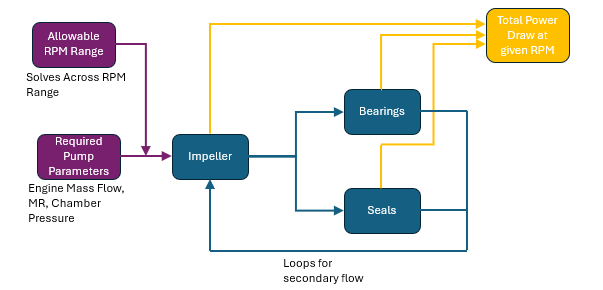

In [101]:
from IPython.display import Image, display
display(Image(filename="Pump Guide Images\\layout.png"))

The general purpose of the sizer is to find which RPM the pump with the given performance parameters will have the lowest power draw. At each RPM, a new pump must be sized (only the parts that affect our simple efficiency calcs). The impeller is sized first, because it has the biggest effect on the downstream components. The bearings and the seal come after that, and then the necessary loops are performed to converge a design.

There are therefore five files, one for each section
1. define Impeller
2. defineBearing
3. defineSeal
4. power, which performs the loops and finds the overall power draw
5. Optimizer, which contains the optimizer itself and will output the final design values

There is also a subfolder that contains the original form of this script, which just plotted power draw against an RPM range, but that is outdated and all information in there will eventually be moved to here.

#### Inputs
The code takes in external inputs that it then uses to run the rest of the script. They are as follows:
1. RPM: This allows for an upper and lower bound for the optimizer. We do not wan't a pump running at 1 million RPM, nor do we want a pump running at 1 RPM. Therefore, we input an acceptable range. This will likely be in the 10k - 30k range, as below that things start to become too big and above that we start reaching problems with critical speeds and COTS component options.
2. Engine mass flow rate and mixture ratio. This allows us to go from vehicle level (more specifically, engine) to the volumetric flow rate needed in the pump
3. Propellant identity. Right now only RP1 is supported, but in the future LOx will be added. This is another reason to do mdot and MR instead of vdot as the input, it allows both to be sized off one input
4. DeltaP. This is a similar one which we take from the vehicle level, and then turn into a pump design parameter (Head)
5. Tank Pressure. This one is only needed across


## Impeller

#### Hydraulic Efficiency


For now, Hydraulic efficiency is just 

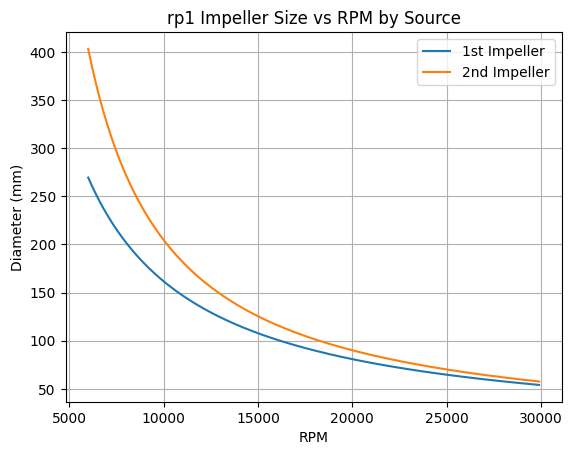

In [102]:
from powerDraw import pumpPowerNotebook
from matplotlib import pyplot as plt

n_vals = range(6000, 30000, 100)
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
imp1_vals = []
imp2_vals = []
imp3_vals = []
for n in n_vals:
    x = (n,1)
    impeller1,impeller2,impeller3,_,_ = pumpPowerNotebook(x,vec)
    imp1_vals.append(impeller1.d_2)
    imp2_vals.append(impeller2.d_2)

imp1_vals = [1000*v for v in imp1_vals]
imp2_vals = [1000*v for v in imp2_vals]

plt.figure()
plt.plot(n_vals, imp1_vals, label="1st Impeller")
plt.plot(n_vals, imp2_vals, label="2nd Impeller")
plt.xlabel("RPM")
plt.ylabel("Diameter (mm)")
plt.title(f"{prop} Impeller Size vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

The reason for the difference between the first and second impeller diameter is that it applies a bump for the efficiency. Impeller 2 and impeller 3 have the exact same 

#### Hydraulic Forces
- assumes beam geometry, maybe should figure out how to do it parametrically i.e. seal diameter defines length between bearings

## Bearings

Bearings are a large source of power loss in this model. Because there is a load applied to the bearings, namely the axial and radial forces, and the bearings have non-negligible friction, some amount of power is drawn by them while the pump is operating. The full description of how this math is done can be found <a href="https://cdn.skfmediahub.skf.com/api/public/0901d1968065e9e7/pdf_preview_medium/0901d1968065e9e7_pdf_preview_medium.pdf" target="_blank">
Here. 
</a>

In the code, this takes the form of defining our bearing object based some inputs. They are:
1. Bearing Type
2. propellant starting temperature
3. allowable temperature change across the bearing
4. propellant identity
5. pressure at the exit of the impeller

We need to know the bearing type because that defines how the bearing will end up taking the load. We have an assumed layout for the pump, where there is an "upper" pair of angular contact bearings, and a "lower" deep groove ball bearing. It is assumed that the upper bearings will take all of the axial load, due to them being AC bearings, while the radial load is split up as if the shaft is a cantilevered beam with the load being applied at the impeller. The propellant temperature matters, as we are assuming flooded upper bearings, and the viscosity (and therefore lubrication performance) varies with temperature. The allowable temperature change is defined by us; this method comes from a nasa file and we select. allowable temp is included in the overall sizing loop because it contains a trade: higher allowable temperature change means less flow and therefore less useful power draw, but also lowers lubrication performance. The pressure is needed for the liquid oxygen viscosity coolProp call. 

The friction is divided into three components. The first is rolling, which happens because the balls deform slightly and form an elliptical contact patch, meaning that different parts of the ball are moving relative to the rings at different speeds. Next is the sliding moment. That comes because the ball bearings will not always be rolling at the exact rpm necessary. Finally, there is drag due to the lubricant. This is large for us due to using flooded bearings, but this model might be overconservative as it doesn't account for incoming swirl that will be generated by the impeller. The math is derived from the skf method, that comes from large amounts of correlations. 

The power draw of the lower bearings is assumed to be a flat 50 watts. This is because, due to the presence of the mechanical seal between the upper and lower bearings, we believe we can apply a lubricant and not have it get swept away by any propellant flow. The number 50 comes from the skf website for power draw, and it is so marginal compared to the rest of the power losses that it is left constant. 

for the upper bearings, certain simplifications are made to allow for more rapid calculations. For now, the dimensions and parameters are set, matching the bearing selected for on notion. In the future, some form of simple bearing selector could be used. 

We can plot the power loss over time of the upper bearings to see how it scales:

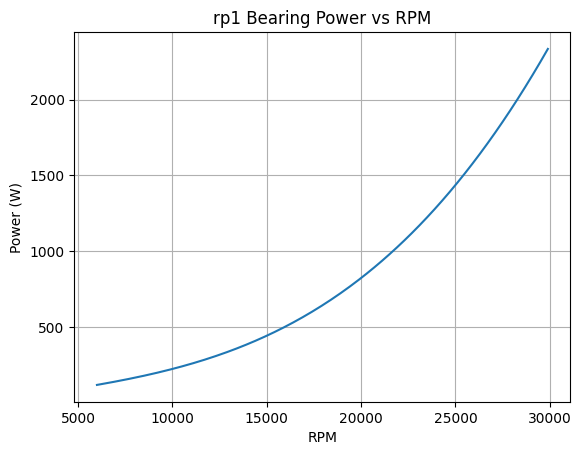

In [103]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",300,3,"rp1",360,135) # remember to change temperature (2nd input) by propellant (300 for rp1, 90 for lox)
example.bearingPlot("AC", 3000, 500)
# The last two arguments are axial and radial forces in Newtons

We can also plot the power loss caused by the various components of friction in order to see which is most significant:

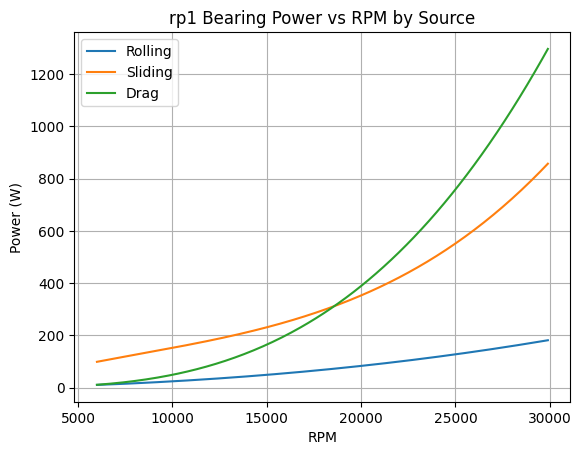

In [104]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",300,3,"rp1",360,135)
example.bearingSourcePlot("AC", 3000, 500)


This makes a decent amount of sense. Drag should have the highest dependence on rpm, as it moves with velocity squared. Rolling has the lowest dependency on rpm, because it happens mainly due to the pressure and the contact ellipse that is formed, creating a smaller, more constant difference in velocity between the balls and the rings. If you convert this bearing type to lox (or view the plots in the appendix), you will see that for lox the drag is lower than sliding across our whole range. This is because the viscosity of lox is almost an order of magnitude lower than the viscosity of rp1

Next, we can compare the sources of friction over various temperature changes to see if the effect matches our intuition.

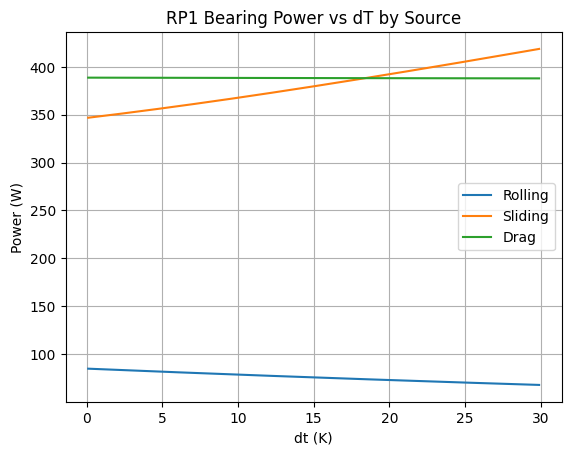

In [105]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt

dt_vals = range(1, 300, 1)
dt_vals = [dt/10 for dt in dt_vals]
proll_vals = []
pslide_vals = []
pdrag_vals = []
for dt in dt_vals:
    example = bearingClass("AC",300,dt,"rp1",360,135)
    example.heating("AC", 20000, 3000, 500)
    proll_vals.append((1.05*(10**(-4)))*(example.M_rr2+example.M_rr)*20000)
    pslide_vals.append((1.05*(10**(-4)))*(example.M_sl2+example.M_sl)*20000)
    pdrag_vals.append((1.05*(10**(-4)))*(example.M_drag2+example.M_drag)*20000)


plt.figure()
plt.plot(dt_vals, proll_vals, label="Rolling")
plt.plot(dt_vals, pslide_vals, label="Sliding")
plt.plot(dt_vals, pdrag_vals, label="Drag")
plt.xlabel("dt (K)")
plt.ylabel("Power (W)")
plt.title("RP1 Bearing Power vs dT by Source")
plt.grid(True)
plt.legend()
plt.show()

This generally follows engineering intuition as it makes sense that the drag component decreases with a decrease in viscosity, but overall there is very little change due to the small magnitude of change in viscosity; For now we choose to continue with this model.

## Seals

For now, we assume that the seal used in this is the John Crane 5xB series seals that have been selected and described on notion. Overall this is the section of the code that makes the most simplifying assumptions with unknown veracity or validation. 

The first of these is 

## Coolant Flow
The coolant flow method comes from a nasa paper linked on the notion. It starts with an assumed allowable change in temperature of the propellant, and then uses a heat capacity (assumed constant for rp1, coolprop for lox) to find the total mass flow rate. The equation is therefore $$ \dot m = \frac{Q}{C_p * \Delta T}$$ We then add the new volumetric flowrate to the old volumetric flowrate to design the new useful power requirement (and resize specific speed to estimate a new hydraulic efficiency) That means there are three seperate impellers that get sized, albeit only the outer diameter and some other simple dimensions. We can plot these against the rpm to see how much they vary on average.

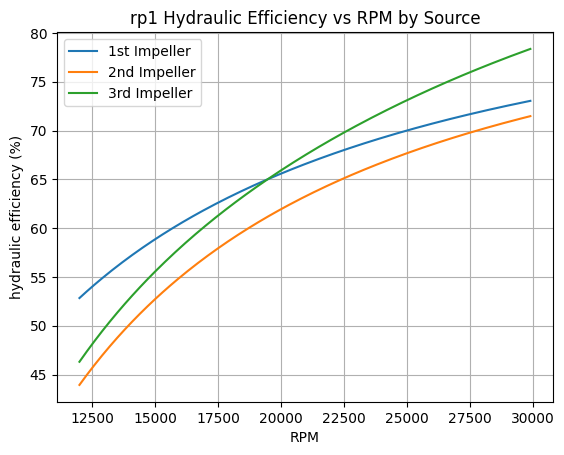

In [106]:
from powerDraw import pumpPowerNotebook
n_vals = range(12000, 30000, 100)
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
imp1_vals = []
imp2_vals = []
imp3_vals = []
for n in n_vals:
    x = (n,1)
    impeller1,impeller2,impeller3,_,_ = pumpPowerNotebook(x,vec)
    imp1_vals.append(impeller1.eta_H)
    imp2_vals.append(impeller2.eta_H)
    imp3_vals.append(impeller3.eta_H)

imp1_vals = [100*v for v in imp1_vals]
imp2_vals = [100*v for v in imp2_vals]
imp3_vals = [100*v for v in imp3_vals]

plt.figure()
plt.plot(n_vals, imp1_vals, label="1st Impeller")
plt.plot(n_vals, imp2_vals, label="2nd Impeller")
plt.plot(n_vals, imp3_vals, label="3rd Impeller")
plt.xlabel("RPM")
plt.ylabel("hydraulic efficiency (%)")
plt.title(f"{prop} Hydraulic Efficiency vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

it makes sense that the second impeller has almost a perpetually lower efficiency than the first. That is because it applies scales for efficiency (with a small adjustment) to get a new head requirement, meaning it has a lower specific speed, correlating to a lower efficiency. Then, to get to the third impeller, a flowrate increase is applied for the bearing recirculation, leading to a reversal of the prior effect.

The required CdA for the coolant flow can be calculated rather easily:

In [107]:
from powerDraw import pumpPowerNotebook
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135
vec = [prop, deltaP, mdot, MR, p_in]
x = (25000,1)
_,_,_,Qcooling,_ = pumpPowerNotebook(x,vec)
rho = 804.59
mdot = Qcooling * rho
CdA = mdot / ((2*rho*deltaP*6894.76)**0.5)
print(f"Required CdA: {CdA} m^2")





Required CdA: 9.603093681259516e-06 m^2


# Results
The general way to run the script is as follows: In order to resize the impeller to begin the epump sizing workflow, change the values in the notebook to see the new optimal rpm and power draw.

In [108]:
from Optimizer import run_epump
results = run_epump(
    prop="rp1",
    deltaP=460,
    mdot=6.17,
    MR=2.23,
    p_in=135
)


Pump Sizing Results
---------------------------------------------
RPM                           :    2.825e+04
flow rate (m^3/s)             :     0.002611
DeltaT (K)                    :            5
Head (m)                      :        401.8
Specific Speed                :        14.28
impeller Diameter (m)         :      0.06197
Reynold's number              :    5.409e+06

Pump Power Results
---------------------------------------------
Power Draw (W)                :     2.26e+04
Gulich's power(W)             :    2.284e+04
Available Power (W)           :     2.26e+04
hydraulic Power (W)           :    1.353e+04
Hydraulic Efficiency          :       0.7173
Mechanical Parasitic Power (W):         9072
Disk Friction Losses (W)      :         4073


In [109]:
from Optimizer import run_epump
results = run_epump(
    prop="lox",
    deltaP=350,
    mdot=6.17,
    MR=2.23,
    p_in=135
)




Pump Sizing Results
---------------------------------------------
RPM                           :    2.457e+04
flow rate (m^3/s)             :     0.003884
DeltaT (K)                    :            5
Head (m)                      :        214.1
Specific Speed                :        26.72
impeller Diameter (m)         :       0.0488
Reynold's number              :    3.484e+07

Pump Power Results
---------------------------------------------
Power Draw (W)                :    1.965e+04
Gulich's power(W)             :    1.577e+04
Available Power (W)           :    1.965e+04
hydraulic Power (W)           :    1.174e+04
Hydraulic Efficiency          :       0.8237
Mechanical Parasitic Power (W):         7912
Disk Friction Losses (W)      :        810.5


### Workflow
The idea for the worklfow is to start with this 1 dimensional script. Inputting values gained from the vehicle sizer will allow us to take this design into further iterations. After initial values are gained from here, more accurate results can be pursued and reinputted into the vehicle sizer to see if altitude is still being reached. Therefore the general workflow for just pumps is as follows:

1. get results from vehicle sizer, input into here
    a. From that, the results that matter are: RPM, DeltaT, Mechanical Power Loss, Hydraulic Efficiency
2. We create an impeller in cfturbo according to sizer guidelines
    a. We need: Geometry, Pump Curve
3. Then, We move on to higher fidelity models
    a. CFD is done to get actual hydraulic efficiency numbers
    b. If created, the more precised bearing calculator is used to improve the bearing estimates, which can then be added to the seal losses from here
4. From that we give to the rest of powerhead:
    a. General dimensions (i.e. volute sizes, shaft length)
    b. Pump Curve from CFturbo or CFD
5. We give to the vehicle sizer power draw, and powerhead gives them general performance parameters. i.e. mass flow rate, thrust.


#### Method Comparison
This is one of the three different methods for sizing the impeller. The other methods rely wholly on the correlations from Gulich's. We can compare these by plotting them against rpm (again keeping deltaT constant)

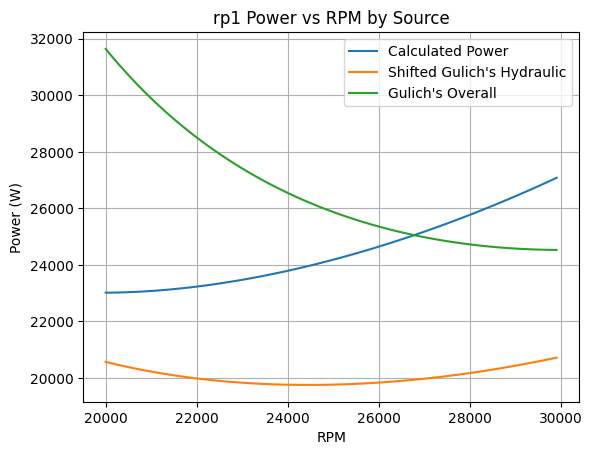

In [110]:
from powerDraw import pumpPowerNotebook
n_vals = range(20000, 30000, 100)
prop="rp1"
deltaP=460
mdot=6.17
MR=2.23
p_in=135

vec = [prop, deltaP, mdot, MR, p_in]
pcalc_vals = []
phgul_vals = []
pogul_vals = []
for n in n_vals:
    x = (n,1)
    _,_,impeller3,_,p = pumpPowerNotebook(x,vec)
    pcalc_vals.append(p)
    phgul_vals.append(1.2*impeller3.p/impeller3.eta_H)
    pogul_vals.append(impeller3.p/impeller3.eta_opt)

plt.figure()
plt.plot(n_vals, pcalc_vals, label="Calculated Power")
plt.plot(n_vals, phgul_vals, label="Shifted Gulich\'s Hydraulic")
plt.plot(n_vals, pogul_vals, label="Gulich\'s Overall")
plt.xlabel("RPM")
plt.ylabel("Power (W)")
plt.title(f"{prop} Power vs RPM by Source")
plt.grid(True)
plt.legend()
plt.show()

The range for rpm is a much smaller rpm range because the overall efficiency increases rapidly as rpm decreases past this point. It's also worth noting that both Gulich's efficiency's scale nonlinearly, not just because of the equation but because the head is increased for lower efficiency, meaning it is somewhat double counted. Problematically, all of these show vastly different minimum points. Although the additional precision added in this script does not neccesarily equate to more accuracy, the increase in specificity does lend itself to viewing this calculation more positively. For that reason, we elect to continue using this calculator.

#### Bearing DeltaT

### Issues

There are a couple issues that exist in this script/workflow. The main one is of course that pretty much every piece of "analysis" here comes from correlations and models that don't apply to this specific pump. Another one is how the model seems to break at some rpm ranges (likely coming from the gulich's correlation.) Those can be seen by doing a 3d plot through a larger range. 

Max Power: 50410589.33133855


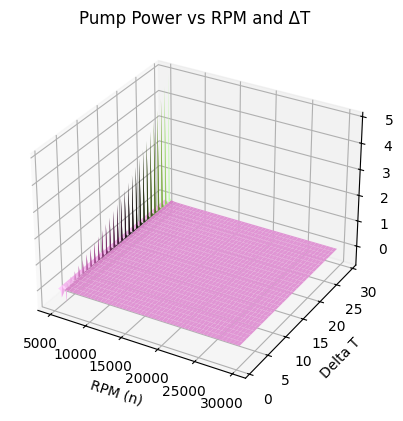

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_vals = np.arange(5000, 30000, 100)
deltat_vals = np.arange(10, 300, 10) / 10

prop = "rp1"
deltaP = 460
mdot = 6.17
MR = 2.23
p_in = 135
vec = [prop, deltaP, mdot, MR, p_in]

## plotting section
# Create meshgrid
N, DT = np.meshgrid(n_vals, deltat_vals)
# Allocate p array
P = np.zeros_like(N, dtype=float)
# Fill grid
for i, dt in enumerate(deltat_vals):
    for j, n in enumerate(n_vals):
        x = (n, dt)
        _, _, _, _, p = pumpPowerNotebook(x, vec)
        P[i, j] = p

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(N, DT, P, cmap='vanimo')

ax.set_xlabel("RPM (n)")
ax.set_ylabel("Delta T")
ax.set_zlabel("Power (W)")
ax.set_title("Pump Power vs RPM and ΔT")
print("Max Power:", max(P.flatten()))
plt.show()


There is clearly something wrong here. My best guess as to what's happening is that the hydraulic efficiency is coming back negative, screwing up. The correlations are therefore definitively proven to be invalid at that range.

## Appendix

#### Lox Bearing Plots

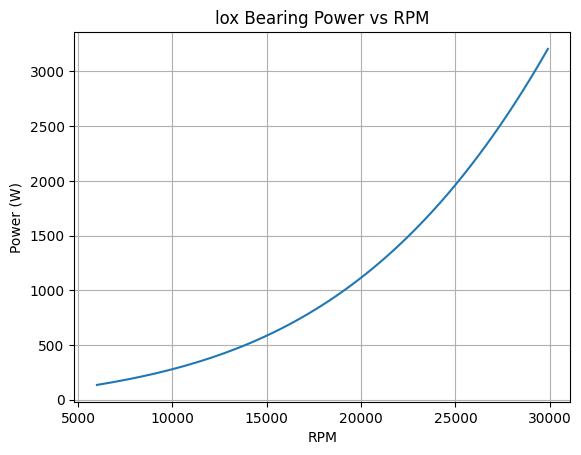

In [112]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",90,3,"lox",360,135) # remember to change temperature (2nd input) by propellant (300 for rp1, 90 for lox)
example.bearingPlot("AC", 3000, 500)
# The last two arguments are axial and radial forces in Newtons

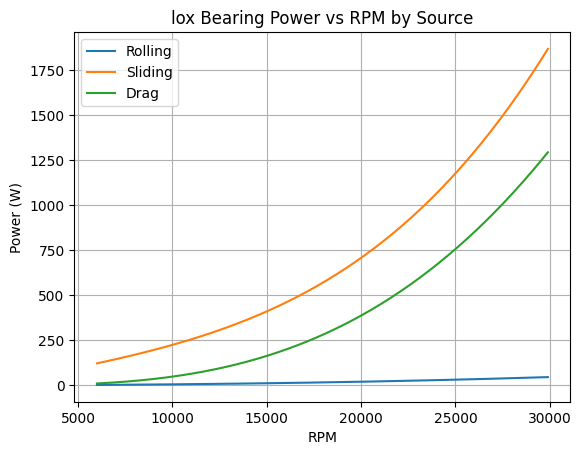

In [113]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt


example = bearingClass("AC",90,3,"lox",360,135)
example.bearingSourcePlot("AC", 3000, 500)


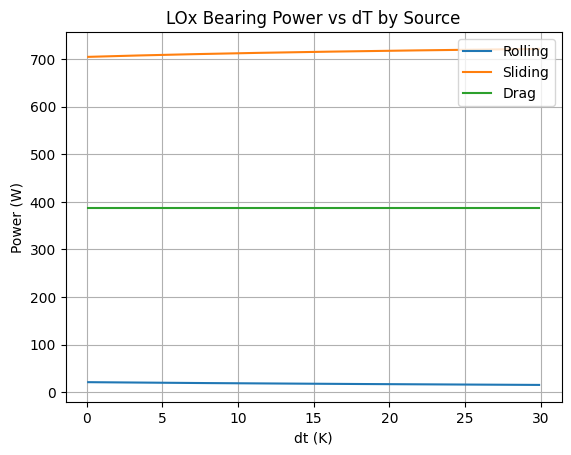

In [114]:
from defineBearing import bearingClass
import matplotlib.pyplot as plt

dt_vals = range(1, 300, 1)
dt_vals = [dt/10 for dt in dt_vals]
proll_vals = []
pslide_vals = []
pdrag_vals = []
for dt in dt_vals:
    example = bearingClass("AC",90,dt,"lox",360,135)
    example.heating("AC", 20000, 3000, 500)
    proll_vals.append((1.05*(10**(-4)))*(example.M_rr2+example.M_rr)*20000)
    pslide_vals.append((1.05*(10**(-4)))*(example.M_sl2+example.M_sl)*20000)
    pdrag_vals.append((1.05*(10**(-4)))*(example.M_drag2+example.M_drag)*20000)


plt.figure()
plt.plot(dt_vals, proll_vals, label="Rolling")
plt.plot(dt_vals, pslide_vals, label="Sliding")
plt.plot(dt_vals, pdrag_vals, label="Drag")
plt.xlabel("dt (K)")
plt.ylabel("Power (W)")
plt.title("LOx Bearing Power vs dT by Source")
plt.grid(True)
plt.legend()
plt.show()

#### Total Design Space

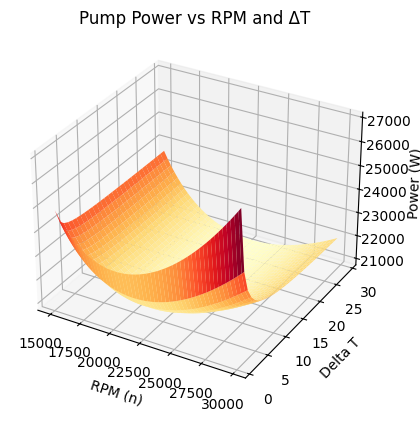

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

n_vals = np.arange(15000, 30000, 100)
deltat_vals = np.arange(10, 300, 10) / 10

prop = "rp1"
deltaP = 460
mdot = 6.17
MR = 2.23
p_in = 135
vec = [prop, deltaP, mdot, MR, p_in]

## plotting section
# Create meshgrid
N, DT = np.meshgrid(n_vals, deltat_vals)
# Allocate p array
P = np.zeros_like(N, dtype=float)
# Fill grid
for i, dt in enumerate(deltat_vals):
    for j, n in enumerate(n_vals):
        x = (n, dt)
        _, _, _, _, p = pumpPowerNotebook(x, vec)
        P[i, j] = p

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(N, DT, P, cmap='YlOrRd')

ax.set_xlabel("RPM (n)")
ax.set_ylabel("Delta T")
ax.set_zlabel("Power (W)")
ax.set_title("Pump Power vs RPM and ΔT")

plt.show()
